# M9 — the faithfulness audit

**Does the reconstruction still describe *this* image, or has the model started drawing from its
prior?**

This notebook measures that, on the **three diffusion checkpoints that already exist** — no new
pretraining. It produces the central figure and the first `t_h` of the follow-up study.

Two axes, both as a function of the extraction timestep `t`:

| axis | what it is | what it cannot do |
|---|---|---|
| **fidelity** — PSNR / SSIM vs the clean original | pixel agreement | say whether the content is *anatomically* plausible. A model that invents a perfectly plausible normal lung scores well. |
| **prior dominance** — disagreement across `K` independent stochastic reconstructions of the same image | how much of the output is decided by the data vs by the prior | — |

Prior dominance is **posterior-sample variance**, the standard uncertainty instrument in
diffusion-based inverse problems. It is *borrowed, not invented*. What is new is using it to pick an
SSL feature-extraction operating point, and (later) to monitor a continually-updated model.

They combine into the **hallucination onset**

$$t_h \;=\; \min\{\,t : \mathrm{PDR}(t) \ge \tau\,\}, \qquad \mathrm{PDR}(t) = \frac{D(t)}{D_{\text{prior}}}$$

— the noise level past which the reconstruction no longer identifies the image it came from.

**Prerequisites.** Run with the working directory set to `papers/OrthoVision/Orthodiffusion`, on the
`ml-env` kernel. `checkpoints/diffusion_seed{0,1,2}.pt` must exist — they do. If one is missing, the
loader will *retrain* it (~40 min), so check first.

In [1]:
import contextlib, io, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# orthoeval.core is the notebook's own definition cells, extracted verbatim
# (scratchpad/extract.py). It prints the encoder and the parity check on import; keep the
# last lines, which are the I1 assertion, and drop the rest.
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    from orthoeval.core import *          # noqa: F401,F403
from orthoeval import faithfulness as fa

print("\n".join(_buf.getvalue().strip().splitlines()[-2:]))
print("device:", DEVICE)

[I1] encoder parity OK across ['diffusion', 'mae', 'jepa', 'supervised']: 4,058,656 params each
arm-specific decoders (outside the parity check): diffusion 899,265 | mae 683,777
device: mps


## Knobs

`SMOKE_AUDIT = True` runs the whole notebook end to end in ~2 minutes on a tiny grid — use it once
to prove the plumbing, then set it to `False`.

The two sweeps are deliberately asymmetric:

* **one-step** is one forward pass per sample, so it runs on the whole test split at `K=8`;
* **full-reverse** is ~50 forward passes per sample, so it runs on a subset.

Full-reverse is the **reported** number (see §4 for why).

In [2]:
SEEDS         = list(CFG.eval.seeds)          # [0, 1, 2]
TS            = [10, 30, 50, 100, 150, 200, 300, 500, 700, 900]
T_ANCHOR      = 999        # defines D_prior, so PDR(T_ANCHOR) == 1 by construction
TAU           = 0.5        # PDR threshold defining t_h; stability over tau is checked in §5

K_ONESTEP     = 8
N_ONESTEP     = None       # None -> the whole test split
K_REVERSE     = 6
N_REVERSE     = 256
REVERSE_STEPS = 50

FAITH_CSV = RESULTS_DIR / "faithfulness.csv"

SMOKE_AUDIT = False
if SMOKE_AUDIT:
    TS = [50, 200, 500]
    K_ONESTEP, K_REVERSE = 3, 3
    N_ONESTEP, N_REVERSE = 64, 32
    REVERSE_STEPS = 20
    FAITH_CSV = RESULTS_DIR / "faithfulness_smoke.csv"

print(f"SMOKE_AUDIT={SMOKE_AUDIT}  ts={TS}  seeds={SEEDS}")
print(f"one-step: K={K_ONESTEP} n={N_ONESTEP or 'all'}   reverse: K={K_REVERSE} n={N_REVERSE} steps={REVERSE_STEPS}")
print("->", FAITH_CSV)

SMOKE_AUDIT=False  ts=[10, 30, 50, 100, 150, 200, 300, 500, 700, 900]  seeds=[0, 1, 2]
one-step: K=8 n=all   reverse: K=6 n=256 steps=50
-> results/faithfulness.csv


## Data and the existing checkpoints

`pretrain_arm` loads from `checkpoints/` when the step count matches, so this cell is a
**load**, not a train. If it starts printing training steps, stop it — a checkpoint is missing or
`pretrain.steps` was changed.

In [3]:
RAW = load_pneumoniamnist(CFG, verbose=True)
DS  = build_datasets(RAW, CFG, smoke=False)

RUNS  = [pretrain_arm("diffusion", s, CFG, DS) for s in SEEDS]
TEST  = eval_tensor(DS["_raw"]["test"], CFG)      # clean, normalized, [N,1,64,64]
TRAIN = eval_tensor(DS["_raw"]["train"], CFG)

print(f"\ntest {tuple(TEST.shape)}  train {tuple(TRAIN.shape)}  "
      f"range [{TEST.min():.2f}, {TEST.max():.2f}]")

PneumoniaMNIST  native=64px  used=64px  task=binary-class
  train n= 4708  x(1, 64, 64)  class0(normal)= 1214  class1(pneumonia)= 3494  pos_rate=0.742
  val   n=  524  x(1, 64, 64)  class0(normal)=  135  class1(pneumonia)=  389  pos_rate=0.742
  test  n=  624  x(1, 64, 64)  class0(normal)=  234  class1(pneumonia)=  390  pos_rate=0.625
[diffusion seed=0] loaded checkpoint (4000 steps, 43m07s)
[diffusion seed=1] loaded checkpoint (4000 steps, 34m49s)
[diffusion seed=2] loaded checkpoint (4000 steps, 37m30s)

test (624, 1, 64, 64)  train (4708, 1, 64, 64)  range [-1.00, 1.00]


## §1 — endpoint sanity

Two things must hold, or the corruption / de-normalization path is wrong and every number below is
meaningless:

* `t → 0` — reconstruction is near-perfect (high PSNR) and the `K` draws agree (`D ≈ 0`);
* `t = T` — the input carries no signal, so the draws are effectively unconditional samples and
  `D` is at its maximum.

These are asserted rather than eyeballed.

In [4]:
_run0 = RUNS[0]
_probe = TEST[:64]
_chk = {}
for _t in (1, T_ANCHOR):
    _r = fa.reconstruct_k(_run0["model"], _probe, _t, K=3, mode="one_step", seed=0)
    _chk[_t] = {
        "psnr": fa.psnr(fa.to01(_r[0]), fa.to01(_probe)).mean().item(),
        "ssim": fa.ssim(fa.to01(_r[0]), fa.to01(_probe)).mean().item(),
        "D":    fa.disagreement(_r).mean().item(),
    }
    print(f"t={_t:4d}  psnr={_chk[_t]['psnr']:6.2f}  ssim={_chk[_t]['ssim']:.4f}  D={_chk[_t]['D']:.4f}")

assert _chk[1]["psnr"] > 25,  "t->0 must reconstruct almost perfectly"
assert _chk[1]["D"] < 0.15 * _chk[T_ANCHOR]["D"], "t->0 draws must agree with each other"
assert _chk[T_ANCHOR]["D"] > 5 * _chk[1]["D"],    "t=T draws must disagree"
print("\nendpoints OK")

t=   1  psnr= 48.15  ssim=0.9969  D=0.0047
t= 999  psnr=  5.59  ssim=0.0421  D=0.9699

endpoints OK


## §2 — the reconstruction ladder

Build this **first**. It carries the paper's claim in three seconds, and it is the fastest way to
notice a bug in the corruption pipeline.

Rows are `x_t`, the reconstruction, and the absolute error. Read left to right: the reconstruction
stops tracking the original and starts drawing a *plausible chest* instead.

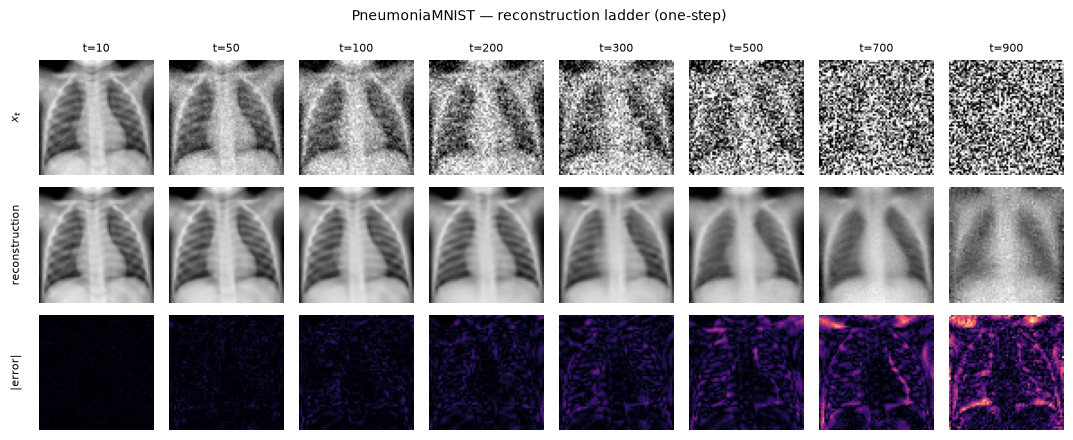

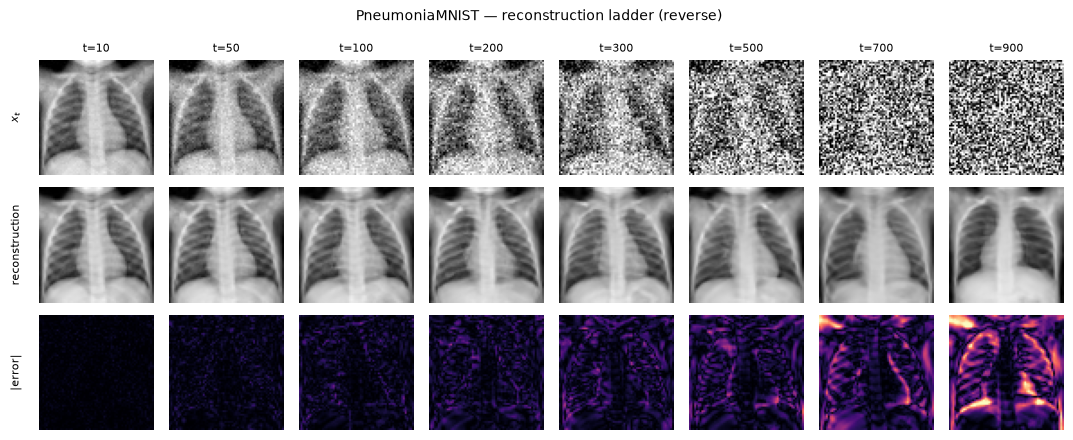

In [5]:
LADDER_TS = [10, 50, 100, 200, 300, 500, 700, 900]
if SMOKE_AUDIT:
    LADDER_TS = [50, 200, 500]

for _mode, _steps in (("one_step", None), ("reverse", REVERSE_STEPS)):
    fa.ladder_figure(
        RUNS[0]["model"], TEST[3:4], LADDER_TS,
        FIG_DIR / f"m9_ladder_pneumonia_{_mode}.png",
        mode=_mode, steps=_steps or 50, seed=0,
        title=f"PneumoniaMNIST — reconstruction ladder ({_mode.replace('_', '-')})",
    )
    plt.show()

## §3 — one-step sweep (whole test split, all seeds)

`x̂₀ = (x_t − √(1−ᾱ_t)·ε̂θ(x_t,t)) / √ᾱ_t` — a single forward pass, so this covers the full grid
cheaply. Expect a couple of minutes.

In [6]:
_imgs = TEST if N_ONESTEP is None else TEST[:N_ONESTEP]
rows_one = []
for run in RUNS:
    print(f"[one_step] seed {run['seed']}  n={_imgs.shape[0]}  K={K_ONESTEP}")
    t0 = time.time()
    r, _ = fa.faithfulness_sweep(run, _imgs, TS, K=K_ONESTEP, tau=TAU,
                                 t_anchor=T_ANCHOR, mode="one_step")
    rows_one += r
    print(f"  t_h={r[0]['t_h']}  ({fmt_time(time.time() - t0)})\n")

df_one = pd.DataFrame(rows_one)
df_one.head()

[one_step] seed 0  n=624  K=8
  t=  10  psnr= 41.49  ssim=0.9873  D=0.0154  ret@1=0.995
  t=  30  psnr= 37.16  ssim=0.9697  D=0.0313  ret@1=0.995
  t=  50  psnr= 35.03  ssim=0.9542  D=0.0438  ret@1=0.995
  t= 100  psnr= 32.12  ssim=0.9210  D=0.0694  ret@1=0.995
  t= 150  psnr= 30.42  ssim=0.8925  D=0.0893  ret@1=0.995
  t= 200  psnr= 29.21  ssim=0.8669  D=0.1040  ret@1=0.995
  t= 300  psnr= 27.48  ssim=0.8225  D=0.1262  ret@1=0.995
  t= 500  psnr= 25.01  ssim=0.7455  D=0.1673  ret@1=0.984
  t= 700  psnr= 22.45  ssim=0.6473  D=0.2647  ret@1=0.670
  t= 900  psnr= 18.26  ssim=0.3992  D=0.6242  ret@1=0.029
  t= 999  psnr=  5.66  ssim=0.0445  D=0.9690  ret@1=0.002
  t_h=822.2777629359139  (1m29s)

[one_step] seed 1  n=624  K=8
  t=  10  psnr= 41.45  ssim=0.9871  D=0.0155  ret@1=0.995
  t=  30  psnr= 37.12  ssim=0.9695  D=0.0318  ret@1=0.995
  t=  50  psnr= 35.00  ssim=0.9540  D=0.0445  ret@1=0.995
  t= 100  psnr= 32.10  ssim=0.9208  D=0.0691  ret@1=0.995
  t= 150  psnr= 30.40  ssim=0.8923  

,arm,seed,t,mode,K,n_images,psnr,ssim,disagreement,pdr,retrieval_at_1,t_h,t_h_ret,tau
0,diffusion,0,10,one_step,8,624,41.487972,0.987292,0.015369,0.015861,0.995192,822.277763,753.000003,0.5
1,diffusion,0,30,one_step,8,624,37.155407,0.969666,0.031291,0.032293,0.995192,822.277763,753.000003,0.5
2,diffusion,0,50,one_step,8,624,35.031322,0.954164,0.043752,0.045153,0.995192,822.277763,753.000003,0.5
3,diffusion,0,100,one_step,8,624,32.120857,0.920984,0.069412,0.071634,0.995192,822.277763,753.000003,0.5
4,diffusion,0,150,one_step,8,624,30.420219,0.892505,0.089322,0.092181,0.995192,822.277763,753.000003,0.5


## §4 — full-reverse sweep (subset) — **the reported numbers**

The one-step estimate is a posterior *mean*: given `x_t` it is deterministic, so the only variation
across the `K` draws comes from the forward noise. That systematically **understates** prior
dominance. The full reverse trajectory is stochastic at every step, and it is what an actual
sampler does.

The plan pre-committed to this: *if the two modes disagree on where `t_h` lands, full-reverse is
what gets reported.* §5 shows the size of the disagreement — it is large, so this matters.

In [7]:
_imgs_r = TEST[:N_REVERSE]
rows_rev = []
for run in RUNS:
    print(f"[reverse] seed {run['seed']}  n={_imgs_r.shape[0]}  K={K_REVERSE}  steps={REVERSE_STEPS}")
    t0 = time.time()
    r, extras = fa.faithfulness_sweep(run, _imgs_r, TS, K=K_REVERSE, tau=TAU,
                                      t_anchor=T_ANCHOR, mode="reverse", steps=REVERSE_STEPS)
    rows_rev += r
    print(f"  t_h={r[0]['t_h']:.1f}  ({fmt_time(time.time() - t0)})\n")

df_rev = pd.DataFrame(rows_rev)

DF = pd.concat([df_one, df_rev], ignore_index=True)
DF.to_csv(FAITH_CSV, index=False)
print(f"wrote {FAITH_CSV}  ({len(DF)} rows)")

[reverse] seed 0  n=256  K=6  steps=50
  t=  10  psnr= 39.12  ssim=0.9789  D=0.0305  ret@1=1.000
  t=  30  psnr= 34.48  ssim=0.9474  D=0.0715  ret@1=1.000
  t=  50  psnr= 32.32  ssim=0.9217  D=0.1030  ret@1=1.000
  t= 100  psnr= 29.51  ssim=0.8737  D=0.1560  ret@1=1.000
  t= 150  psnr= 27.91  ssim=0.8365  D=0.1937  ret@1=1.000
  t= 200  psnr= 26.78  ssim=0.8056  D=0.2231  ret@1=1.000
  t= 300  psnr= 25.17  ssim=0.7550  D=0.2674  ret@1=1.000
  t= 500  psnr= 22.85  ssim=0.6777  D=0.3300  ret@1=0.977
  t= 700  psnr= 20.42  ssim=0.5963  D=0.4015  ret@1=0.582
  t= 900  psnr= 16.66  ssim=0.4642  D=0.5061  ret@1=0.027
  t= 999  psnr= 14.80  ssim=0.4175  D=0.5125  ret@1=0.008
  t_h=274.9  (12m36s)

[reverse] seed 1  n=256  K=6  steps=50
  t=  10  psnr= 39.10  ssim=0.9787  D=0.0306  ret@1=1.000
  t=  30  psnr= 34.47  ssim=0.9472  D=0.0716  ret@1=1.000
  t=  50  psnr= 32.30  ssim=0.9214  D=0.1030  ret@1=1.000
  t= 100  psnr= 29.51  ssim=0.8737  D=0.1555  ret@1=1.000
  t= 150  psnr= 27.92  ssim=0

## §5 — the curves, `t_h`, and the τ-stability check

τ = 0.5 is a **reported hyperparameter, not a hidden one** — if `t_h` moves a lot across
τ ∈ [0.4, 0.6] the quantity is partly an artifact of the threshold. The table below is that check.

> **Read this table before trusting any `t_h` above.** On a coarse grid the smoke run gave
> `t_h` = 181 / 309 / 460 for τ = 0.4 / 0.5 / 0.6 in reverse mode — a 2.5× swing — while one-step
> moved only ±9%. If the swing survives the full 10-point grid, `t_h` must be reported **as a range
> over τ**, not as a point estimate, and the label-free selection rule has to be fit against that
> range. This check exists precisely to stop a τ-artifact from being written up as a finding.

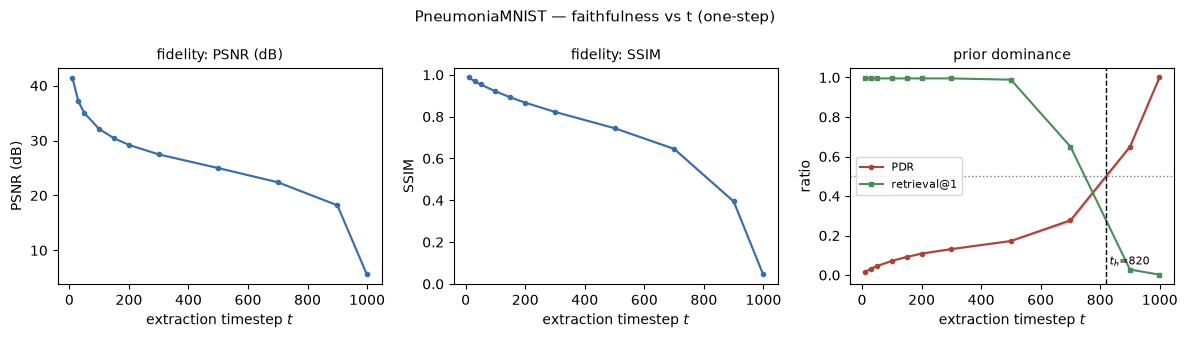

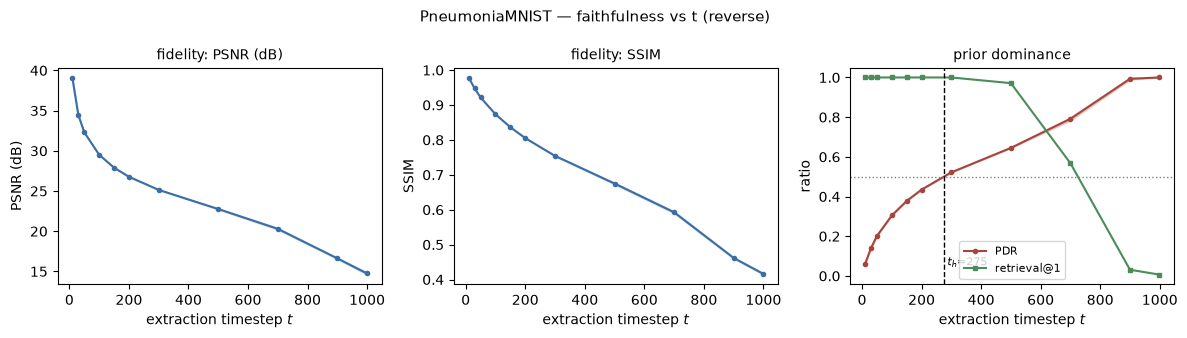

t_h by mode, seed and tau
----------------------------------------------


seed              0      1      2   mean
mode     tau                            
one_step 0.4  768.4  762.5  767.0  766.0
         0.5  822.3  817.3  819.3  819.6
         0.6  876.2  872.2  871.6  873.3
reverse  0.4  169.2  170.6  168.4  169.4
         0.5  274.9  274.5  275.0  274.8
         0.6  428.2  424.4  427.5  426.7

In [8]:
for _mode in ("one_step", "reverse"):
    sub = DF[DF["mode"] == _mode]
    fa.curves_figure(sub, FIG_DIR / f"m9_curves_pneumonia_{_mode}.png", tau=TAU,
                     title=f"PneumoniaMNIST — faithfulness vs t ({_mode.replace('_', '-')})")
    plt.show()

print("t_h by mode, seed and tau\n" + "-" * 46)
tau_rows = []
for _mode in ("one_step", "reverse"):
    for _seed in SEEDS:
        s = DF[(DF["mode"] == _mode) & (DF["seed"] == _seed)].sort_values("t")
        for _tau in (0.4, 0.5, 0.6):
            tau_rows.append({
                "mode": _mode, "seed": _seed, "tau": _tau,
                "t_h": fa.hallucination_onset(s["t"], s["pdr"], tau=_tau),
            })
TAU_TBL = pd.DataFrame(tau_rows).pivot_table(index=["mode", "tau"], columns="seed", values="t_h")
TAU_TBL["mean"] = TAU_TBL.mean(axis=1)
display(TAU_TBL.round(1))

## §6 — does `t_h` sit above the representation optimum `t*`?

This is the hypothesis the whole follow-up study rests on. `t*` comes from the **existing**
`results/results.csv` (the M5 ablation, block `mid2`, test AUROC); `t_h` comes from §4.

The prediction: **`t*` < `t_h`** — features are best just *below* the point where the model starts
inventing. If that holds here and on other datasets, `t_h` becomes a label-free way to choose `t`,
which is the answer to F6 (val AUROC is too saturated — 0.9929–0.9941 — to select `t` honestly).

A single dataset cannot establish this. It can only fail to refute it, which is what this cell
checks.

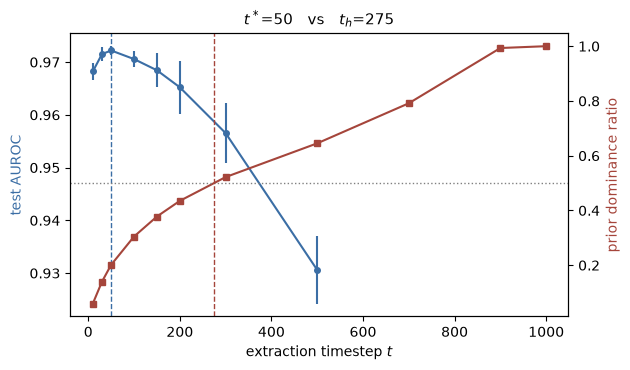

t*  (representation optimum, val-independent argmax on test) = 50
t_h (hallucination onset, label-free, reverse mode)          = 274.8
ratio t*/t_h = 0.182

prediction t* < t_h: HOLDS


In [9]:
res = pd.read_csv(RESULTS_DIR / "results.csv")
abl = res[(res.arm == "diffusion") & (res.protocol == "probe") &
          (res.split == "test") & (res.label_frac == 1.0) & (res.block == "mid2")]
auroc_by_t = abl.groupby("t").auroc.agg(["mean", "std"])
t_star = float(auroc_by_t["mean"].idxmax())

rev = DF[DF["mode"] == "reverse"]
t_h_mean = float(rev.groupby("seed").t_h.first().mean())
pdr_by_t = rev.groupby("t").pdr.mean()

fig, ax1 = plt.subplots(figsize=(6.4, 3.8))
ax1.errorbar(auroc_by_t.index, auroc_by_t["mean"], yerr=auroc_by_t["std"].fillna(0),
             marker="o", ms=4, color="#3b6ea5", label="probe AUROC (existing M5)")
ax1.axvline(t_star, ls="--", lw=1, color="#3b6ea5")
ax1.set_xlabel("extraction timestep $t$"); ax1.set_ylabel("test AUROC", color="#3b6ea5")
ax2 = ax1.twinx()
ax2.plot(pdr_by_t.index, pdr_by_t.values, marker="s", ms=4, color="#a5453b", label="PDR (reverse)")
ax2.axhline(TAU, ls=":", lw=1, color="grey")
ax2.axvline(t_h_mean, ls="--", lw=1, color="#a5453b")
ax2.set_ylabel("prior dominance ratio", color="#a5453b")
ax1.set_title(f"$t^*$={t_star:.0f}   vs   $t_h$={t_h_mean:.0f}", fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "m9_tstar_vs_th.png", dpi=140); plt.show()

print(f"t*  (representation optimum, val-independent argmax on test) = {t_star:.0f}")
print(f"t_h (hallucination onset, label-free, reverse mode)          = {t_h_mean:.1f}")
print(f"ratio t*/t_h = {t_star / t_h_mean:.3f}")
print("\nprediction t* < t_h:", "HOLDS" if t_star < t_h_mean else "REFUTED on this dataset")

## §7 — memorization control

Reviewers of medical generative work ask this one. If unconditional samples sit much closer to
**train** images than to **test** images, the model memorized patients rather than learning an
anatomy prior, and every "prior dominance" reading above means something different.

Ratio ≈ 1 is the healthy answer.

The banks are **subsampled to equal size** (`match_bank_size=True`). Without that the test is
confounded — this train split is 7.5× the test split, and a bigger bank supplies a closer nearest
neighbour for free, pushing the ratio below 1 whether or not anything was memorized.

mean NN distance to train = 12.8513
mean NN distance to test  = 13.0279
ratio (train/test)        = 0.9864   <- ~1.0 means a prior, not memorized patients


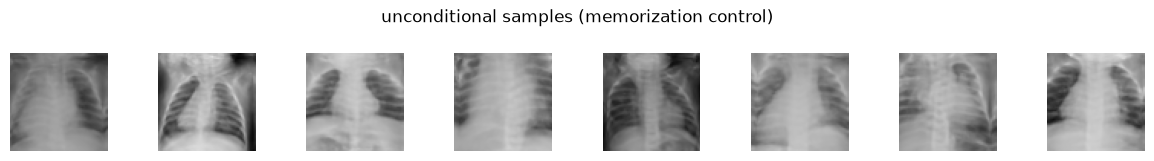

In [10]:
_n_samp = 16 if SMOKE_AUDIT else 64
with label_blind():
    samples = RUNS[0]["model"].diffusion.sample(
        RUNS[0]["model"], _n_samp, (CFG.data.in_channels, CFG.data.size, CFG.data.size),
        steps=CFG.diffusion.sample_steps, eta=CFG.diffusion.sample_eta,
        device=DEVICE, seed=0,
    ).cpu()

ratio, d_tr, d_te = fa.memorization_ratio(samples, TRAIN, TEST)
print(f"mean NN distance to train = {d_tr:.4f}")
print(f"mean NN distance to test  = {d_te:.4f}")
print(f"ratio (train/test)        = {ratio:.4f}   <- ~1.0 means a prior, not memorized patients")

show_grid(samples[:8], "unconditional samples (memorization control)",
          FIG_DIR / "m9_memorization_samples.png")

## §8 — what this notebook established

Fill these in from the cells above when you write the paper section:

| quantity | value | where |
|---|---|---|
| `t_h` (reverse, τ=0.5, mean over seeds) | §5 | the label-free operating-point bound |
| `t_h` (one-step) | §5 | understates prior dominance — do not report as the headline |
| `t*` (existing M5 ablation) | §6 | the representation optimum to beat |
| memorization ratio | §7 | must be ≈ 1 for §5 to mean what we say it means |

**Next**, in order of value per hour of compute:

1. Repeat this notebook on a second dataset (BreastMNIST is the cheapest, and its 546 training
   images make it the most likely place for the memorization control in §7 to *fail* — which would
   itself be worth reporting).
2. Only once `t_h` looks sane on two datasets: start the MRNet 128px pretraining runs, since that
   is the long pole and the part that decides the venue.
3. Then the streams — the continual-learning experiment reuses this exact instrument as its
   label-free drift signal.